# DIFFEDIT: DIFFUSION-BASED SEMANTIC IMAGE EDITING WITH MASK GUIDANCE


DIFFEDIT, a method to take advantage of text-conditioned diffusion models for the task of semantic image editing, where the goal is to edit an image based on a text query. Semantic image editing is an extension of image generation, with the additional constraint that the generated image should be as similar as possible to a given input image. Current editing methods based on diffusion models usually require to provide a mask, making the task much easier by treating it as a conditional inpainting task. In contrast, our main contribution is able to automatically generate a mask highlighting regions of the input image that need to be edited, by contrasting predictions of a diffusion model conditioned on different text prompts. Moreover, we rely on latent inference to preserve content in those regions of interest and show excellent synergies with mask-based diffusion.



## Setup and imports

In [1]:
!pip install -q --upgrade transformers==4.25.1 diffusers ftfy accelerate matplotlib torchvision scipy


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from base64 import b64encode

import numpy
import torch
from diffusers import AutoencoderKL, LMSDiscreteScheduler, UNet2DConditionModel
from huggingface_hub import notebook_login

# For video display:
from IPython.display import HTML
from matplotlib import pyplot as plt
from pathlib import Path
from PIL import Image
from torch import autocast
from torchvision import transforms as tfms
from tqdm.auto import tqdm
from transformers import CLIPTextModel, CLIPTokenizer, logging
import os

torch.manual_seed(1)
if not (Path.home()/'.cache/huggingface'/'token').exists(): notebook_login()

# Supress some unnecessary warnings when loading the CLIPTextModel
logging.set_verbosity_error()

# Set device
torch_device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
if "mps" == torch_device: os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = "1"

/Users/ricardomatos/.pyenv/versions/3.9.18/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ricardomatos/.pyenv/versions/3.9.18/lib/python3.9/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


## Loading models

In [3]:
# Load the autoencoder model which will be used to decode the latents into image space.
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

# Load the tokenizer and text encoder to tokenize and encode the text.
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")

# The UNet model for generating the latents.
unet = UNet2DConditionModel.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="unet")

# The noise scheduler
scheduler = LMSDiscreteScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000)

# To the GPU we go!
vae = vae.to(torch_device)
text_encoder = text_encoder.to(torch_device)
unet = unet.to(torch_device); 

/Users/ricardomatos/.pyenv/versions/3.9.18/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## DiffEdif Loop

### Step 1: Compute Mask

In [4]:
# Some settings
prompt = ["A Zebra"]
height = 512                        # default height of Stable Diffusion
width = 512                         # default width of Stable Diffusion
num_inference_steps = 30            # Number of denoising steps
guidance_scale = 7.5                # Scale for classifier-free guidance
generator = torch.manual_seed(32)   # Seed generator to create the inital latent noise
gaussian_strength = 0.5
batch_size = 1

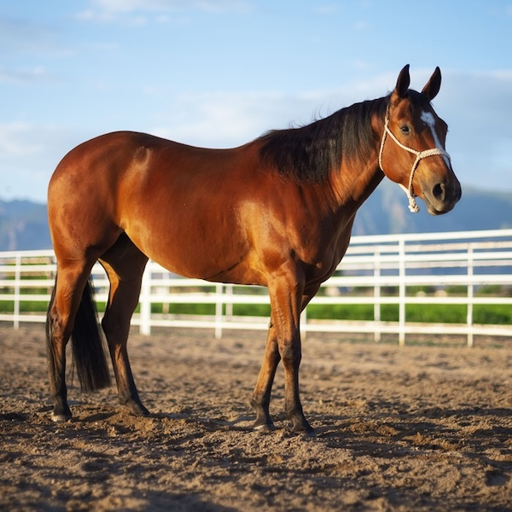

In [5]:
# prepare image
img = Image.open('./horse.jpg').resize((512, 512))
img

In [6]:
# convert image to tensor
img_tensor = tfms.ToTensor()(img).unsqueeze(0).to(torch_device)*2-1
img_tensor.size()

torch.Size([1, 3, 512, 512])

In [7]:
# add noise to the image
def add_stabilized_gaussian_noise(
    img_tensor,
    gaussian_strength = 0.5,
    generator = None,
    device = "mps"
):

  noise = torch.randn(
    img_tensor.shape,
    generator=generator
  ).to(device)

  noisy_img_tensor = img_tensor + noise * gaussian_strength

  noisy_img_tensor = torch.clamp(noisy_img_tensor, -1, 1)

  return noisy_img_tensor

noisy_img_tensor = img_tensor

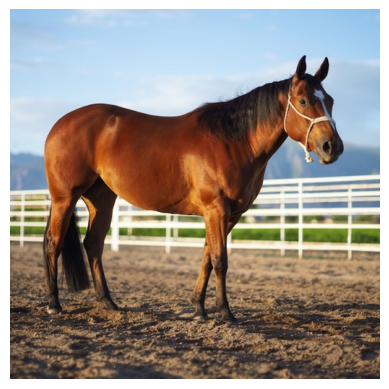

In [8]:
def visualize_tensor_as_rgb(tensor, batch_idx=0):
    tensor = torch.clamp(tensor, -1, 1)
    tensor = (tensor + 1) / 2

    # Select the image from the batch if needed
    if tensor.dim() == 4:
        tensor = tensor[batch_idx]

    img_np = tensor.squeeze().cpu().detach().numpy()
    img_np = numpy.transpose(img_np, (1, 2, 0))  # (H, W, C)

    # Display
    plt.imshow(img_np)
    plt.axis('off')
    plt.show()

visualize_tensor_as_rgb(noisy_img_tensor)

In [9]:
# rescale back to [0, 1]
# noisy_img_tensor = (noisy_img_tensor + 1) / 2

In [10]:
def pil_to_latent(input_im_tensor):
    # Single image -> single latent in a batch (so size 1, 4, 64, 64)
    with torch.no_grad():
        latent = vae.encode(input_im_tensor) # Note scaling
    return 0.18215 * latent.latent_dist.sample()

def latents_to_pil(latents):
    # bath of latents -> list of images
    latents = (1 / 0.18215) * latents
    with torch.no_grad():
        image = vae.decode(latents).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
    images = (image * 255).round().astype("uint8")
    pil_images = [Image.fromarray(image) for image in images]
    return pil_images

In [11]:
encoded = pil_to_latent(noisy_img_tensor)
encoded = add_stabilized_gaussian_noise(encoded, gaussian_strength=gaussian_strength, generator=generator,device=torch_device) ## Might be wrong
encoded.shape

torch.Size([1, 4, 64, 64])

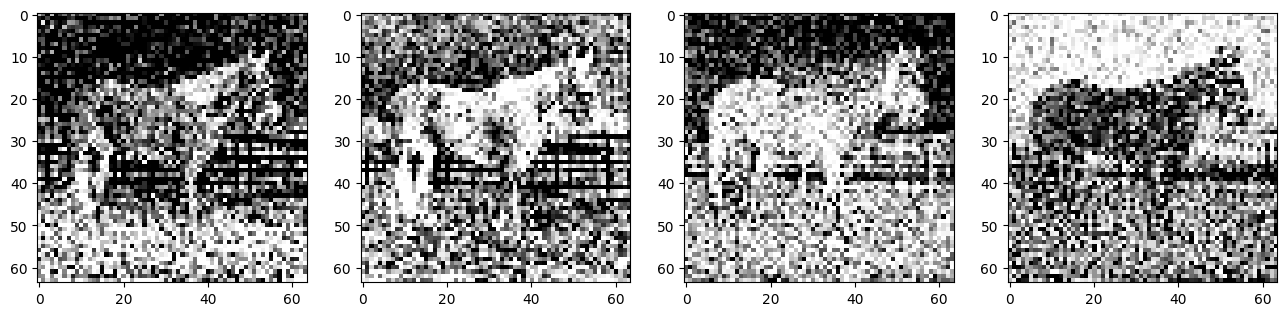

In [12]:
# Let's visualize the four channels of this latent representation:
def visualize_latent_channels(encoded):
  fig, axs = plt.subplots(1, 4, figsize=(16, 4))
  for c in range(4):
    axs[c].imshow(encoded[0][c].cpu(), cmap='Greys')

visualize_latent_channels(encoded)

Let's estimate noise base on the reference text R ("A Zebra") and on an uncoditional query Q ("")

In [13]:
# Prep text
text_input = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]
max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer(
    [""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt"
)
with torch.no_grad():
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0]
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

In [14]:
# Prep latents
latents = encoded

In [15]:
def estimate_noise_based_on_embeddings(latents):
  latent_model_input = torch.cat([latents] * 2)

  # predict the noise residual
  with torch.no_grad():
    noise_pred = unet(latent_model_input, 0, encoder_hidden_states=text_embeddings).sample


  noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

  return noise_pred_uncond, noise_pred_text

noise_pred_uncond, noise_pred_text = estimate_noise_based_on_embeddings(latents)

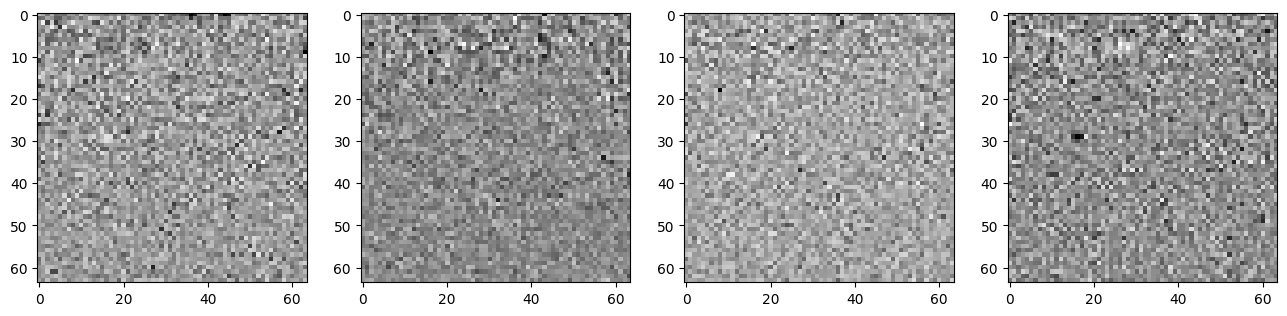

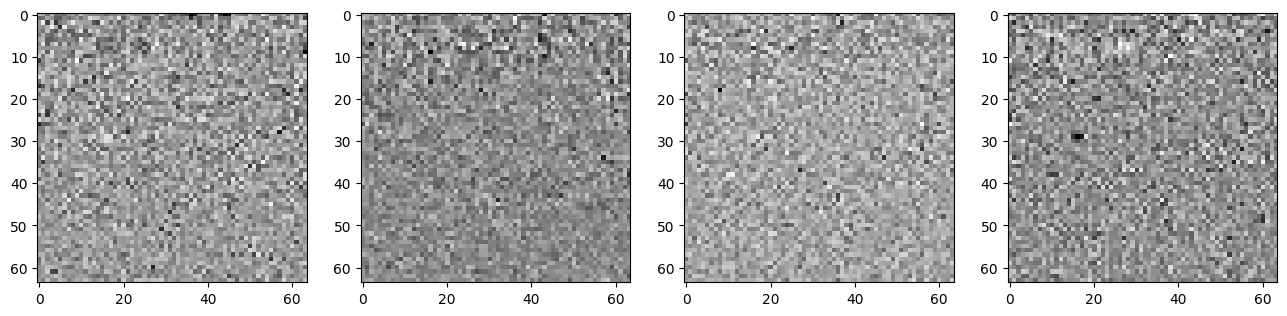

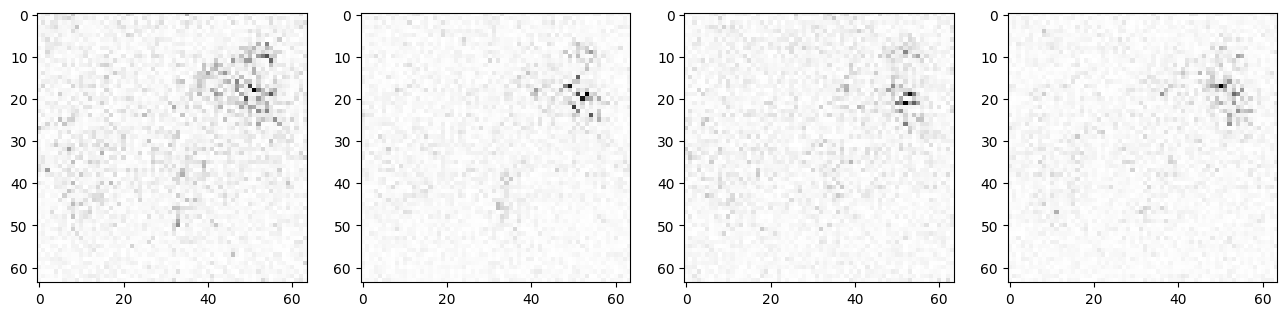

In [16]:
visualize_latent_channels(noise_pred_text)
visualize_latent_channels(noise_pred_uncond)


diff = torch.abs(noise_pred_text - noise_pred_uncond) 
visualize_latent_channels(diff)

In [17]:
## compute mask
difference = diff.mean(dim=0)

normalized_diff = (
    difference - difference.min()
) / (
    difference.max() - difference.min()
)

mask = (normalized_diff > 0.15).float()


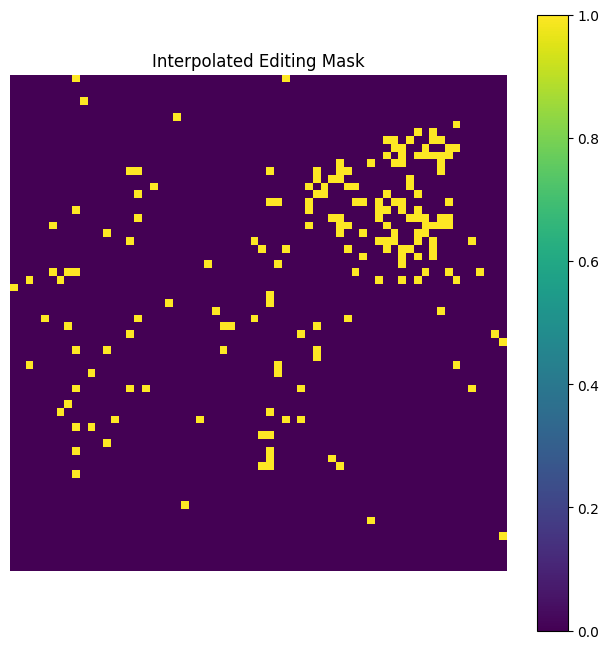

In [18]:
# Take first image in batch
mask_img = mask.unsqueeze(1)[0, 0].detach().cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(mask_img)
plt.colorbar()
plt.title("Interpolated Editing Mask")
plt.axis("off")
plt.show()

Now, let's put everything together and stabilize the effect.

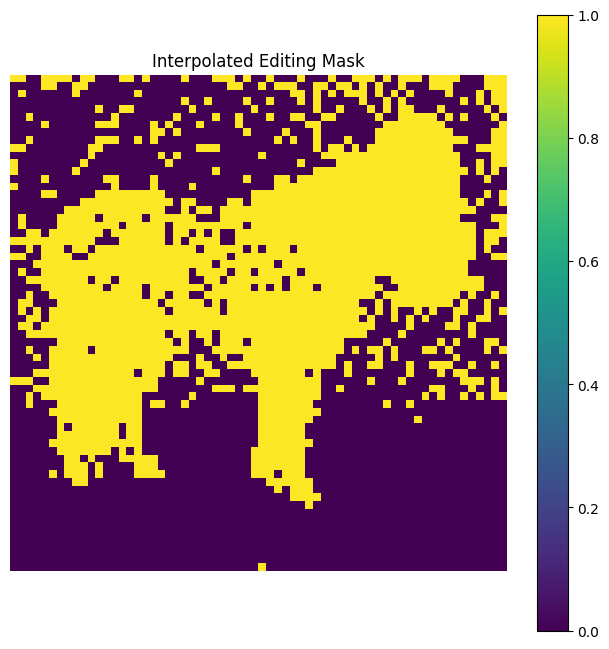

In [19]:
all_differences = []
n_noises = 10
latent = pil_to_latent(noisy_img_tensor)

for i in range(n_noises):
  
  noisy_latent = add_stabilized_gaussian_noise(latent, gaussian_strength=gaussian_strength, generator=generator,device=torch_device)

  noise_pred_uncond, noise_pred_text = estimate_noise_based_on_embeddings(noisy_latent)

  diff = torch.abs(noise_pred_text - noise_pred_uncond)

  all_differences.append(diff)

difference = torch.stack(all_differences).mean(dim=0).mean(dim=1)

difference = (
    difference - difference.min()
) / (
    difference.max() - difference.min()
)


mask = (difference > 0.10).float()


# Take first image in batch
mask_img = mask.unsqueeze(1)[0, 0].detach().cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(mask_img)
plt.colorbar()
plt.title("Interpolated Editing Mask")
plt.axis("off")
plt.show()

### Step 2: DDIM encoding + Step 3: Decoding with mask guidance. 

In [20]:
# Prep Scheduler
def set_timesteps(scheduler, num_inference_steps):
    scheduler.set_timesteps(num_inference_steps)
    scheduler.timesteps = scheduler.timesteps.to(torch.float32) # minor fix to ensure MPS compatibility, fixed in diffusers PR 3925

In [21]:
encoded = pil_to_latent(img_tensor)

In [22]:
print(scheduler.timesteps)

tensor([999., 998., 997., 996., 995., 994., 993., 992., 991., 990., 989., 988.,
        987., 986., 985., 984., 983., 982., 981., 980., 979., 978., 977., 976.,
        975., 974., 973., 972., 971., 970., 969., 968., 967., 966., 965., 964.,
        963., 962., 961., 960., 959., 958., 957., 956., 955., 954., 953., 952.,
        951., 950., 949., 948., 947., 946., 945., 944., 943., 942., 941., 940.,
        939., 938., 937., 936., 935., 934., 933., 932., 931., 930., 929., 928.,
        927., 926., 925., 924., 923., 922., 921., 920., 919., 918., 917., 916.,
        915., 914., 913., 912., 911., 910., 909., 908., 907., 906., 905., 904.,
        903., 902., 901., 900., 899., 898., 897., 896., 895., 894., 893., 892.,
        891., 890., 889., 888., 887., 886., 885., 884., 883., 882., 881., 880.,
        879., 878., 877., 876., 875., 874., 873., 872., 871., 870., 869., 868.,
        867., 866., 865., 864., 863., 862., 861., 860., 859., 858., 857., 856.,
        855., 854., 853., 852., 851., 85

In [23]:

def ddim_encode():
  x = encoded   # x_0
  inversion_latents = []

  for i, t in enumerate(scheduler.timesteps):
      
      x = scheduler.add_noise(encoded, noise, timesteps=torch.tensor([scheduler.timesteps[i]]))

      inversion_latents.append(x)

  return inversion_latents

100%|██████████| 30/30 [00:05<00:00,  5.93it/s]


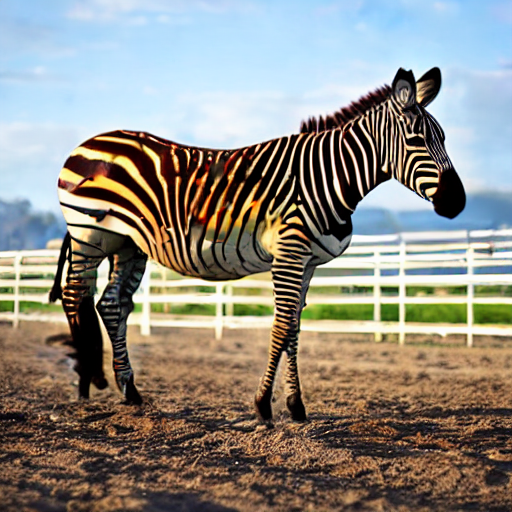

In [24]:
# Prep Scheduler (setting the number of inference steps)
set_timesteps(scheduler, num_inference_steps)

# Prep latents (noising appropriately for start_step)
start_step = 10
start_sigma = scheduler.sigmas[start_step]
noise = torch.randn_like(encoded)
inversion_latents = ddim_encode()
latents = scheduler.add_noise(encoded, noise, timesteps=torch.tensor([scheduler.timesteps[start_step]]))
latents = latents.to(torch_device).float()

# Loop
for i, t in tqdm(enumerate(scheduler.timesteps), total=len(scheduler.timesteps)):
    if i >= start_step: # << This is the only modification to the loop we do

        # expand the latents if we are doing classifier-free guidance to avoid doing two forward passes.
        latent_model_input = torch.cat([latents] * 2)
        sigma = scheduler.sigmas[i]
        latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        # predict the noise residual
        with torch.no_grad():
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings)["sample"]

        # perform guidance
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        latents = scheduler.step(noise_pred, t, latents).prev_sample


        # compute the previous noisy sample x_t -> x_t-1
        # --------------------------------
        # MASK GUIDANCE
        # --------------------------------

        x_t = inversion_latents[i]

        latents = (
            mask * latents
            + (1 - mask) * x_t
        )

latents_to_pil(latents)[0]